In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    KFold, LeaveOneOut, RandomizedSearchCV,
    StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

### Merging tables

In [2]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

## Tabela de Resultados

In [3]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Somente Potência Delta e Teta'
classifier_name = 'Linear SVM'

pasta_saida = 'features_extraidas_ec'
nome_arquivo_saida = 'features_potencia.csv' 

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Tabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("Tabela criada com sucesso.")

Tabela já existe. Registros atuais: 13


In [4]:
bands = {
    'Delta': (0.1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

X_features = []
y_labels = []
feature_names = []
patient_ids = []
eeg_folder = './cleaned_ec' 

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

### Extração das Features

In [5]:
biomarcadores = []

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    pain_score = float(row['Actual Pain'])
    
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")

    if os.path.exists(path):
        try:
            # Carregar as épocas do arquivo
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            sfreq = epochs.info['sfreq']
            
            # Ajuste do n_fft para 2048 (ou o limite máximo do segmento)
            n_fft = 2048 if sfreq * 5.0 >= 2048 else int(sfreq * 5.0)
            
            # Cálculo do PSD com o método de Welch
            psd = epochs.compute_psd(method='welch', fmin=1, fmax=70, n_fft=n_fft, n_overlap=0, verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            # psd_data formato: (n_epochs, n_channels, n_freqs)
            
            # 1. Calcular a média ao longo das épocas (axis=0), preservando os canais
            psd_epochs_mean = psd_data.mean(axis=0) 
            
            patient_features = {}
            
            # Obter a potência média dentro de cada banda
            for band_name, (fmin, fmax) in bands.items():
                band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                
                # Média das frequências da banda para todos os canais
                power_per_channel = np.mean(psd_epochs_mean[:, band_idx], axis=1)
                
                # 2. Salvar cada canal como uma feature independente
                for ch_idx, ch_name in enumerate(epochs.ch_names):
                    patient_features[f'PSD_{band_name}_{ch_name}'] = power_per_channel[ch_idx]
                
                # 3. Calcular e salvar a média geral de todos os canais para esta banda
                global_mean = np.mean(power_per_channel)
                patient_features[f'PSD_{band_name}_Global'] = global_mean
            
            biomarcadores.append(patient_features)
            patient_ids.append(patient_id)
            y_labels.append(pain_score)
            
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

# Criar o DataFrame final
df_biomarcadores = pd.DataFrame(biomarcadores)
df_biomarcadores['patient_id'] = patient_ids
df_biomarcadores['pain_score'] = y_labels

# Exibir os resultados
display(df_biomarcadores.head())

# Criar o DataFrame final
df_biomarcadores = pd.DataFrame(biomarcadores)
df_biomarcadores['patient_id'] = patient_ids
df_biomarcadores['pain_score'] = y_labels

# Exibir os resultados
display(df_biomarcadores.head())

# --- SALVAR A TABELA EM UM ARQUIVO CSV NA PASTA ESPECIFICADA ---
os.makedirs(pasta_saida, exist_ok=True)
caminho_csv = os.path.join(pasta_saida, 'features_potencia_delta_teta.csv')
df_biomarcadores.to_csv(caminho_csv, index=False)
print(f"\nTabela salva com sucesso no arquivo: {caminho_csv}")

Processamento do paciente 0 finalizado.
Processamento do paciente 1 finalizado.
Processamento do paciente 2 finalizado.
Processamento do paciente 3 finalizado.
Processamento do paciente 4 finalizado.
Processamento do paciente 5 finalizado.
Processamento do paciente 6 finalizado.
Processamento do paciente 7 finalizado.
Processamento do paciente 8 finalizado.
Processamento do paciente 9 finalizado.
Processamento do paciente 10 finalizado.
Processamento do paciente 11 finalizado.
Processamento do paciente 13 finalizado.
Processamento do paciente 15 finalizado.
Processamento do paciente 16 finalizado.
Processamento do paciente 18 finalizado.
Processamento do paciente 19 finalizado.
Processamento do paciente 20 finalizado.
Processamento do paciente 21 finalizado.
Processamento do paciente 22 finalizado.
Processamento do paciente 23 finalizado.
Processamento do paciente 24 finalizado.
Processamento do paciente 25 finalizado.
Processamento do paciente 26 finalizado.
Processamento do paciente 

,PSD_Delta_FP1,PSD_Delta_FP2,PSD_Delta_F3,PSD_Delta_F4,PSD_Delta_C3,PSD_Delta_C4,PSD_Delta_P3,PSD_Delta_P4,PSD_Delta_O1,PSD_Delta_O2,...,PSD_Gamma_Cz,PSD_Gamma_Pz,PSD_Gamma_M1,PSD_Gamma_M2,PSD_Gamma_AFz,PSD_Gamma_CPz,PSD_Gamma_POz,PSD_Gamma_Global,patient_id,pain_score
0,1.518712e-13,2.189287e-14,1.121172e-14,4.520818e-15,3.316093e-15,3.410214e-15,6.236899e-15,4.820691e-15,3.803863e-14,1.864534e-14,...,2.350458e-14,2.603579e-14,1.123357e-13,9.086008e-14,8.421716e-14,2.015024e-14,7.068926e-14,1.454438e-13,0,7.0
1,4.869739e-14,2.034831e-14,4.148802e-14,7.389094e-14,1.551769e-14,2.408313e-14,5.184721e-15,1.472272e-14,6.602265e-15,2.342172e-14,...,3.169208e-14,3.209578e-14,1.632789e-13,2.398901e-13,5.912020e-14,3.027985e-14,3.348754e-14,1.853765e-13,1,4.0
2,5.810246e-15,7.694438e-15,1.282968e-14,2.327438e-14,7.570894e-15,1.498682e-14,1.203038e-13,2.848667e-13,1.466336e-14,2.875744e-14,...,1.175479e-14,2.989795e-14,1.112770e-13,6.000321e-14,1.659827e-14,1.321941e-14,3.647009e-14,5.537722e-14,2,3.0
3,1.685167e-14,2.169483e-14,5.932070e-15,8.199925e-15,3.656704e-15,4.504012e-15,3.383313e-15,8.809018e-15,1.118645e-14,1.132799e-14,...,1.354103e-14,1.815193e-14,3.301755e-14,3.680047e-14,3.714052e-14,1.623163e-14,1.838160e-14,5.311985e-14,3,8.0
4,3.408053e-15,3.489612e-15,4.859306e-15,3.533284e-15,1.491939e-14,2.857545e-15,2.501208e-15,2.805160e-15,4.583213e-15,5.583318e-15,...,1.428796e-14,1.574710e-14,3.484031e-13,4.384973e-14,2.133883e-14,2.477456e-12,3.664452e-14,1.638471e-13,4,5.0


,PSD_Delta_FP1,PSD_Delta_FP2,PSD_Delta_F3,PSD_Delta_F4,PSD_Delta_C3,PSD_Delta_C4,PSD_Delta_P3,PSD_Delta_P4,PSD_Delta_O1,PSD_Delta_O2,...,PSD_Gamma_Cz,PSD_Gamma_Pz,PSD_Gamma_M1,PSD_Gamma_M2,PSD_Gamma_AFz,PSD_Gamma_CPz,PSD_Gamma_POz,PSD_Gamma_Global,patient_id,pain_score
0,1.518712e-13,2.189287e-14,1.121172e-14,4.520818e-15,3.316093e-15,3.410214e-15,6.236899e-15,4.820691e-15,3.803863e-14,1.864534e-14,...,2.350458e-14,2.603579e-14,1.123357e-13,9.086008e-14,8.421716e-14,2.015024e-14,7.068926e-14,1.454438e-13,0,7.0
1,4.869739e-14,2.034831e-14,4.148802e-14,7.389094e-14,1.551769e-14,2.408313e-14,5.184721e-15,1.472272e-14,6.602265e-15,2.342172e-14,...,3.169208e-14,3.209578e-14,1.632789e-13,2.398901e-13,5.912020e-14,3.027985e-14,3.348754e-14,1.853765e-13,1,4.0
2,5.810246e-15,7.694438e-15,1.282968e-14,2.327438e-14,7.570894e-15,1.498682e-14,1.203038e-13,2.848667e-13,1.466336e-14,2.875744e-14,...,1.175479e-14,2.989795e-14,1.112770e-13,6.000321e-14,1.659827e-14,1.321941e-14,3.647009e-14,5.537722e-14,2,3.0
3,1.685167e-14,2.169483e-14,5.932070e-15,8.199925e-15,3.656704e-15,4.504012e-15,3.383313e-15,8.809018e-15,1.118645e-14,1.132799e-14,...,1.354103e-14,1.815193e-14,3.301755e-14,3.680047e-14,3.714052e-14,1.623163e-14,1.838160e-14,5.311985e-14,3,8.0
4,3.408053e-15,3.489612e-15,4.859306e-15,3.533284e-15,1.491939e-14,2.857545e-15,2.501208e-15,2.805160e-15,4.583213e-15,5.583318e-15,...,1.428796e-14,1.574710e-14,3.484031e-13,4.384973e-14,2.133883e-14,2.477456e-12,3.664452e-14,1.638471e-13,4,5.0



Tabela salva com sucesso no arquivo: features_extraidas_ec\features_potencia_delta_teta.csv


### Treinamento SVM (LOO) - Somente Delta


Avaliando Linear SVM (Somente Biomarcadores Delta) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 28.6%
LOO AUC-ROC: 0.289

Melhores hiperparâmetros: {'svm_final__C': 10.0}
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM):
  1. PSD_Delta_Cz: 9.1% de importância
  2. PSD_Delta_C4: 8.4% de importância
  3. PSD_Delta_Fz: 8.0% de importância
  4. PSD_Delta_P8: 6.9% de importância
  5. PSD_Delta_F3: 6.5% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 5 BIOMARCADORES:
  1. PSD_Delta_Cz: Coeficiente = 2.5624 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  2. PSD_Delta_C4: Coeficiente = 2.3786 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  3. PSD_Delta_Fz: Coe

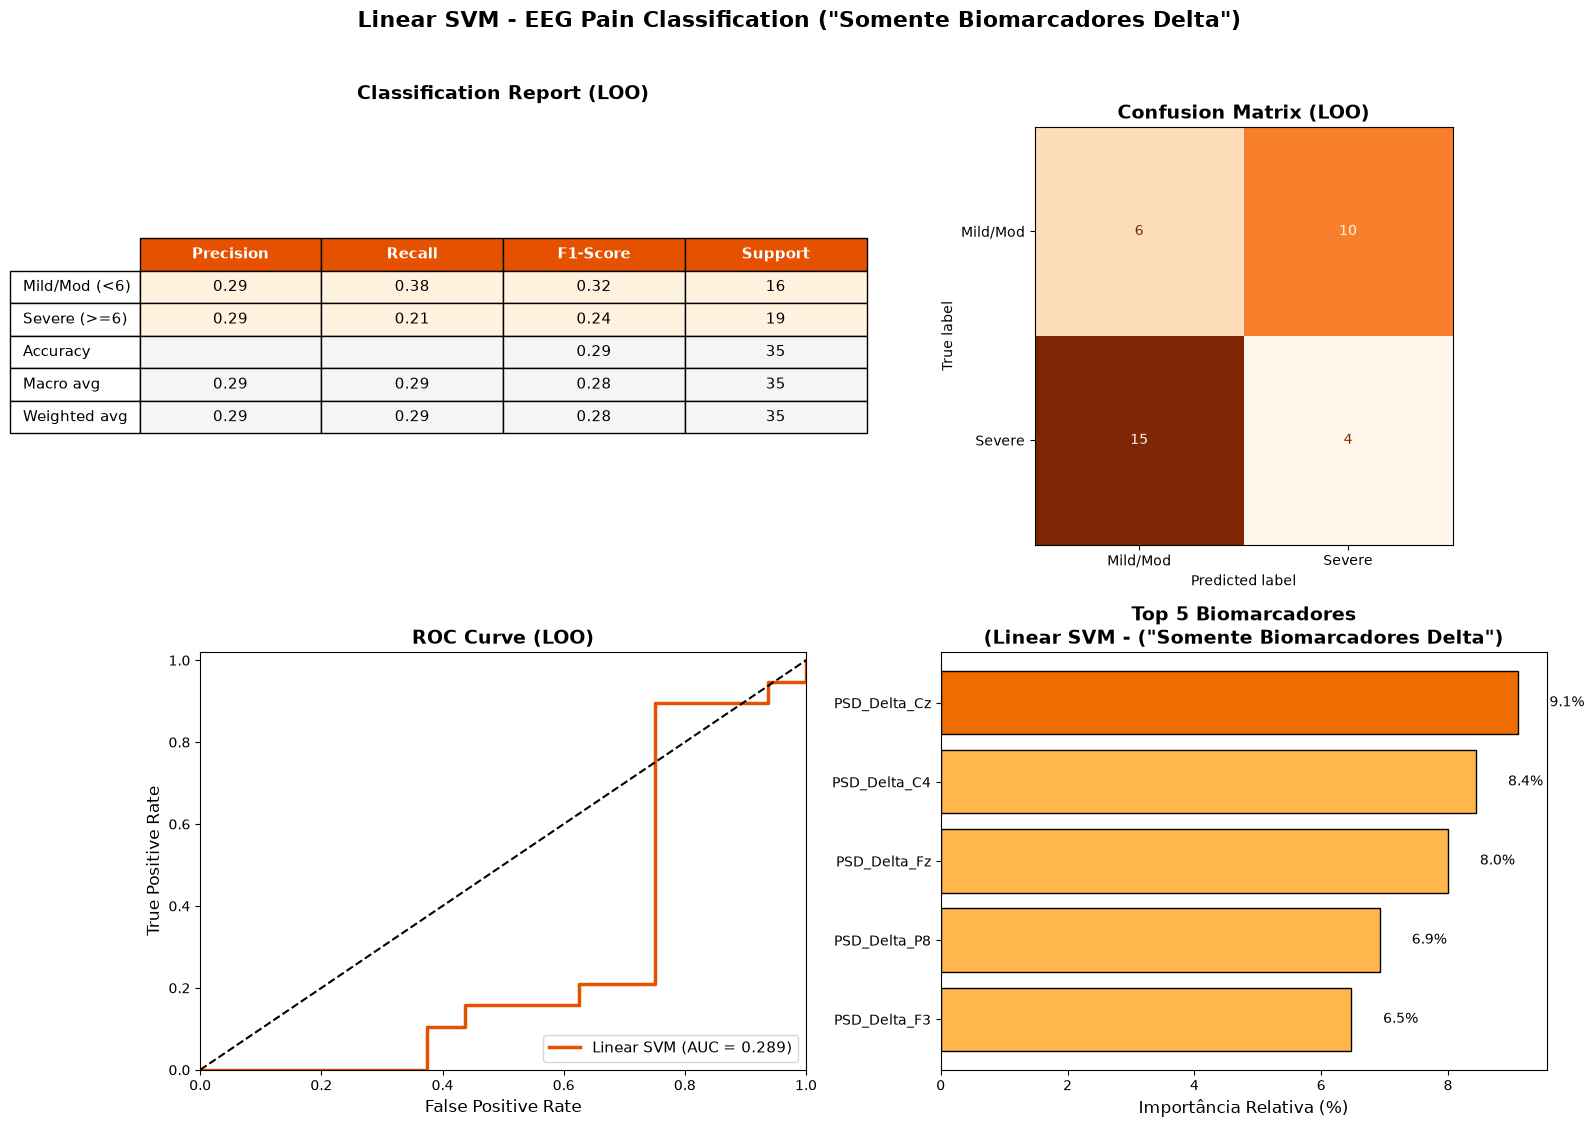


Gráfico salvo como: images\01_psd_delta_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [6]:
# 1. Definir os nomes das features extraindo as colunas, ignorando ID e Target
# 1. Definir os nomes das features extraindo APENAS as colunas referentes a Delta
feature_names = [col for col in df_biomarcadores.columns if 'Delta' in col]

# 2. Criar a matriz X (features) e o vetor y (labels)
X = df_biomarcadores[feature_names].values
y = df_biomarcadores['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} (Somente Biomarcadores Delta) - class_weight='balanced', LOO + RandomizedSearchCV")
    # ... (restante do código permanece inalterado)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número de features para exibir no gráfico de barras

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO NOVO BLOCO ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO NOVO BLOCO ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - ("Somente Biomarcadores Delta")', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ("Somente Biomarcadores Delta")', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_psd_delta_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': 'Somente Biomarcadores Delta',
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

### Treinamento SVM (LOO) - Somente Teta


Avaliando Linear SVM (Somente Biomarcadores Teta) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 25.7%
LOO AUC-ROC: 0.253

Melhores hiperparâmetros: {'svm_final__C': 0.5}
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM):
  1. PSD_Theta_F3: 15.8% de importância
  2. PSD_Theta_P7: 10.3% de importância
  3. PSD_Theta_C4: 10.0% de importância
  4. PSD_Theta_FP2: 7.7% de importância
  5. PSD_Theta_F8: 7.0% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 5 BIOMARCADORES:
  1. PSD_Theta_F3: Coeficiente = -0.9117 (-)
     -> Uma potência maior nesta região DIMINUI a probabilidade matemática de Dor Severa (Classe 1).
  2. PSD_Theta_P7: Coeficiente = 0.5926 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  3. PSD_Theta_C4: 

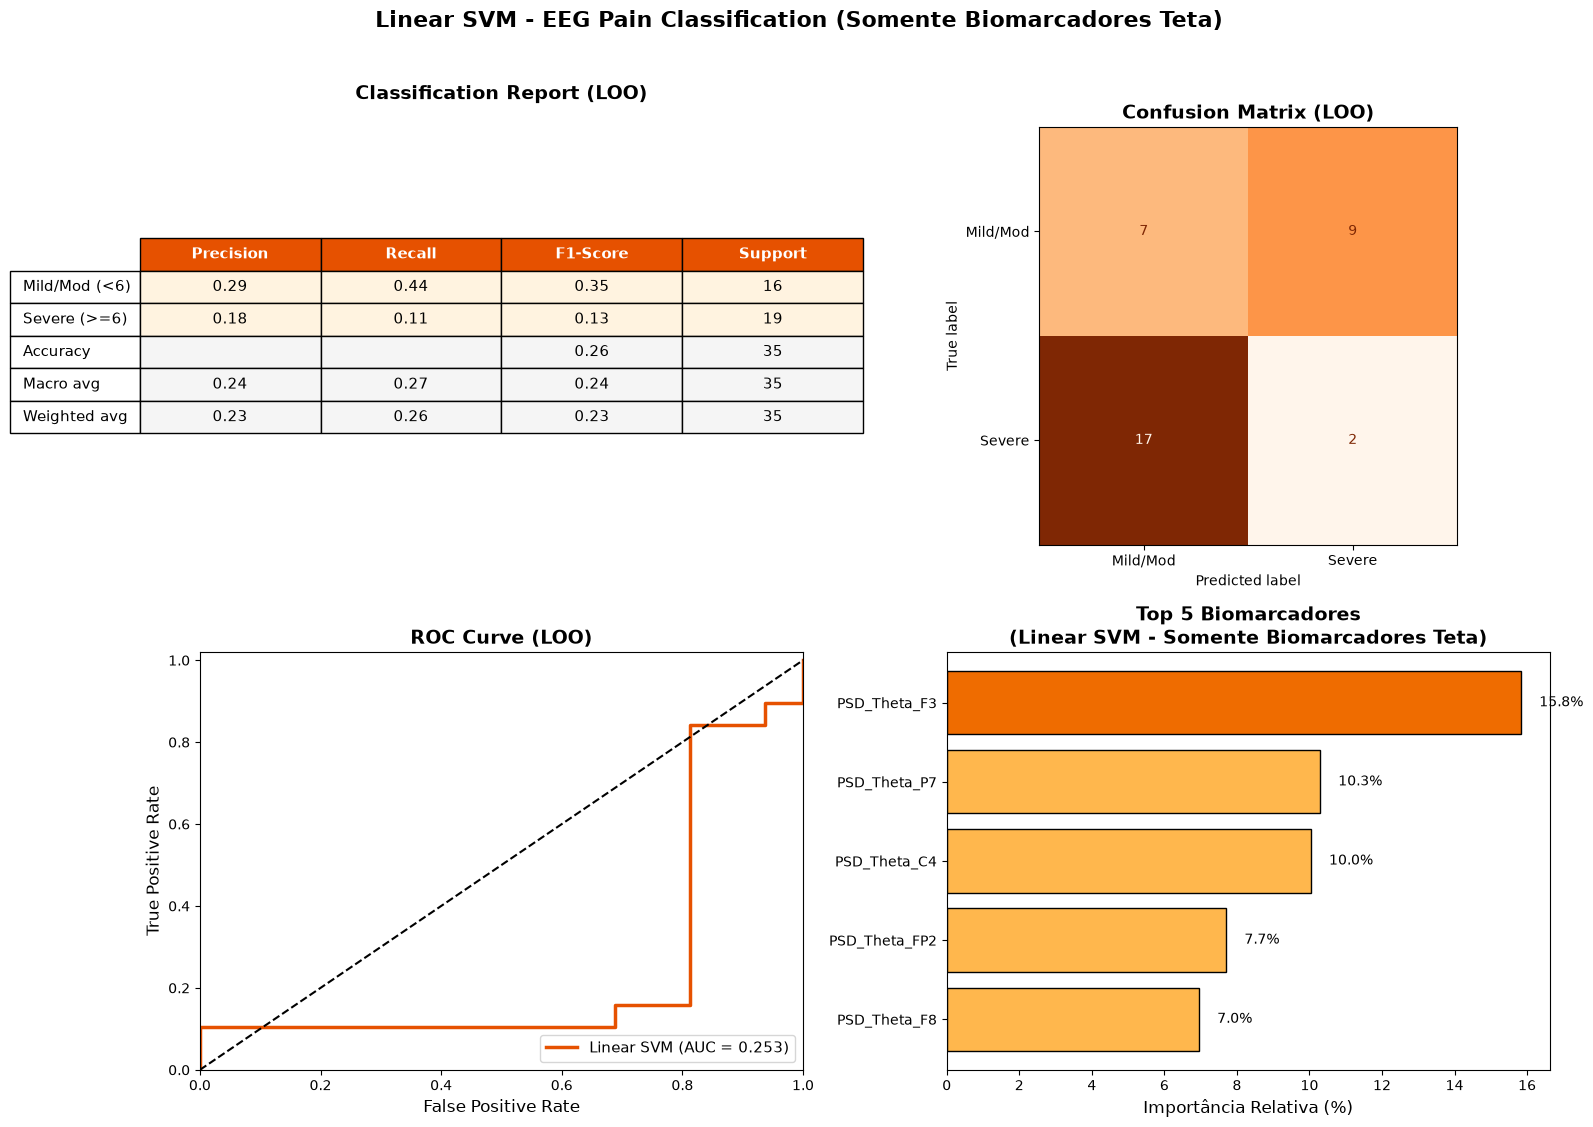


Gráfico salvo como: images\01_psd_theta_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [7]:
# 1. Definir os nomes das features extraindo APENAS as colunas referentes a Theta (Teta)
feature_names = [col for col in df_biomarcadores.columns if 'Theta' in col]
current_category = "Somente Biomarcadores Teta"

# 2. Criar a matriz X (features) e o vetor y (labels)
X = df_biomarcadores[feature_names].values
y = df_biomarcadores['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número de features para exibir no gráfico de barras

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO NOVO BLOCO ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO NOVO BLOCO ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_psd_theta_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

### Treinamento SVM (LOO) -  Delta e Teta


Avaliando Linear SVM (Biomarcadores Delta e Teta) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 20.0%
LOO AUC-ROC: 0.227

Melhores hiperparâmetros: {'svm_final__C': 1.0}
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM):
  1. PSD_Delta_P7: 5.9% de importância
  2. PSD_Delta_Cz: 5.0% de importância
  3. PSD_Delta_AFz: 4.7% de importância
  4. PSD_Delta_Fz: 4.5% de importância
  5. PSD_Delta_F3: 4.0% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 5 BIOMARCADORES:
  1. PSD_Delta_P7: Coeficiente = 0.8988 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  2. PSD_Delta_Cz: Coeficiente = 0.7607 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  3. PSD_Delta_AFz: Coe

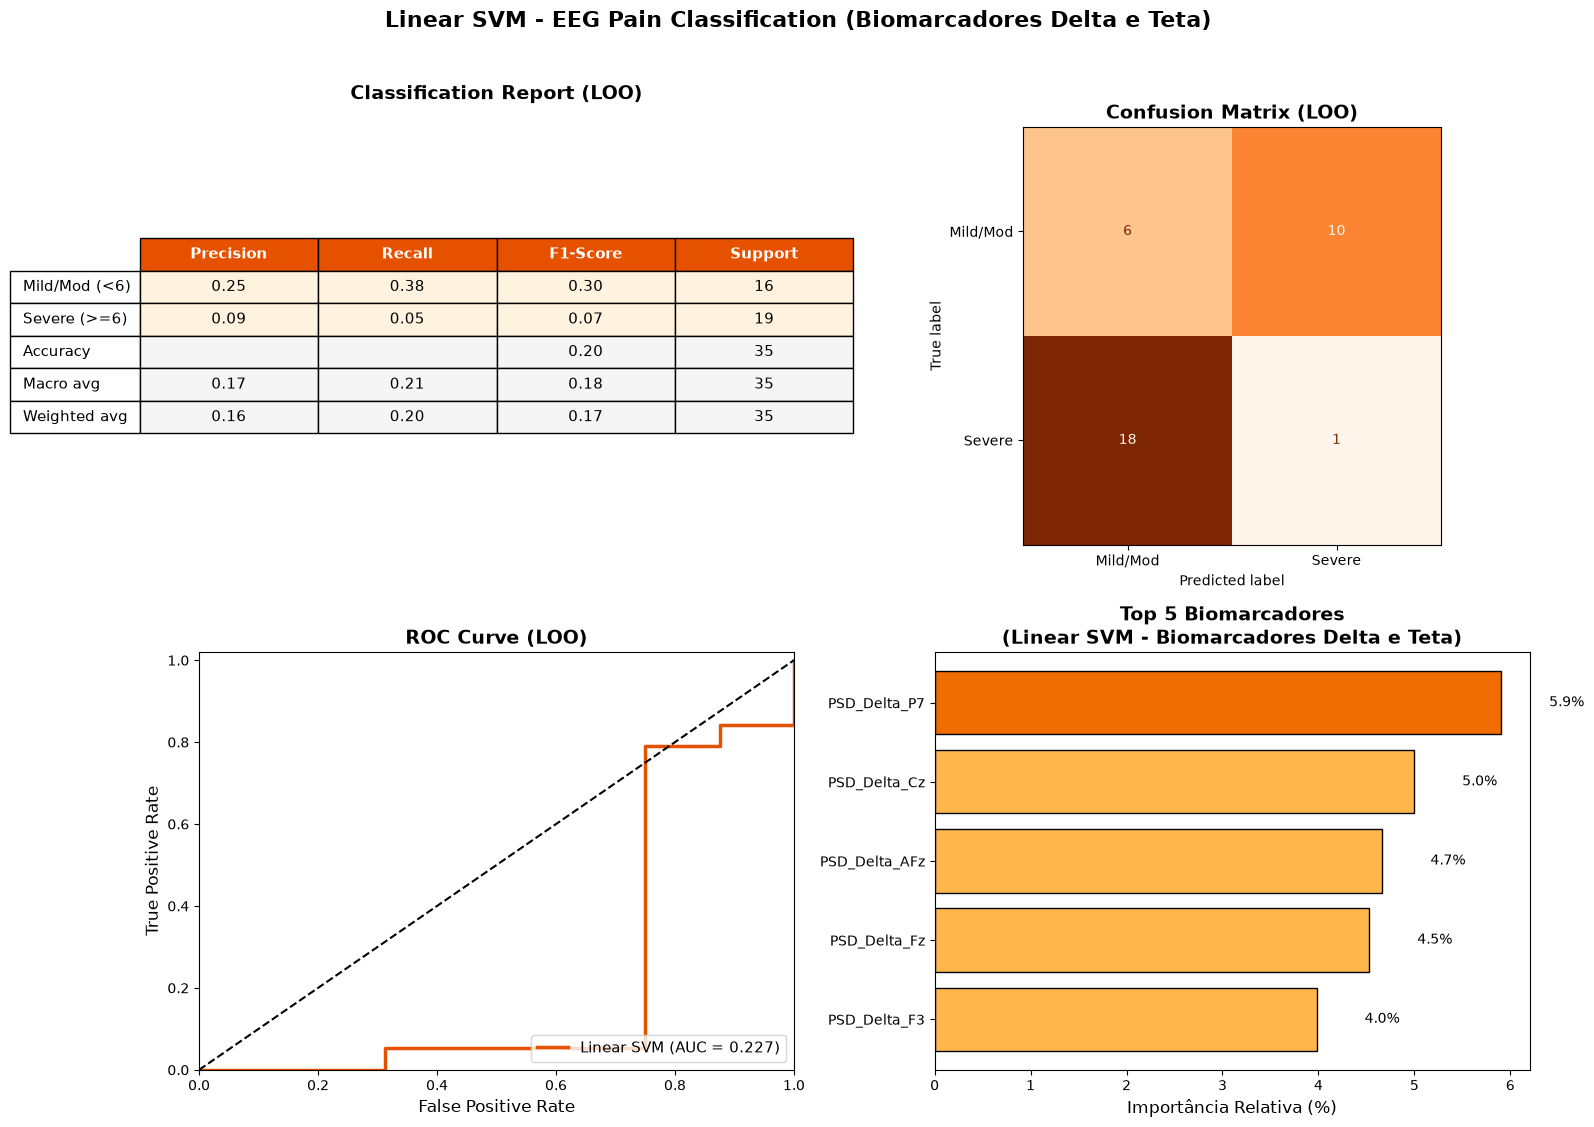


Gráfico salvo como: images\01_psd_delta_teta_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [8]:
# 1. Definir os nomes das features extraindo as colunas referentes a Delta OU Theta (Teta)
feature_names = [col for col in df_biomarcadores.columns if 'Delta' in col or 'Theta' in col]
current_category = "Biomarcadores Delta e Teta"

# 2. Criar a matriz X (features) e o vetor y (labels)
X = df_biomarcadores[feature_names].values
y = df_biomarcadores['pain_score'].values

# O seu código original continua a partir daqui:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número de features para exibir no gráfico de barras

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # --- INÍCIO DO NOVO BLOCO ---
    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO NOVO BLOCO ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_psd_delta_teta_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

### Treinamento SVM (LOO) - Somente Delta e Teta (RFE)


Avaliando Linear SVM (Delta e Teta (RFE + SVM)) - class_weight='balanced', LOO + RandomizedSearchCV + RFE
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV com RFE...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 22.9%
LOO AUC-ROC: 0.148

Melhores hiperparâmetros: {'svm_final__C': 1.0, 'rfe__step': 1, 'rfe__n_features_to_select': 5}
-------------------------------------------------------

TOP 5 BIOMARCADORES SELECIONADOS (Linear SVM + RFE):
  1. PSD_Delta_C4: 29.2% de importância
  2. PSD_Delta_F3: 24.4% de importância
  3. PSD_Theta_F3: 20.1% de importância
  4. PSD_Theta_FP2: 18.6% de importância
  5. PSD_Delta_P7: 7.6% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 5 BIOMARCADORES:
  1. PSD_Delta_C4: Coeficiente = 1.0528 (+)
     -> Uma potência maior nesta região AUMENTA a probabilidade matemática de Dor Severa (Classe 1).
  2. PSD_Delta_F3: Coeficiente = -0.8794 (-)
     -> Uma potência maior nesta região 

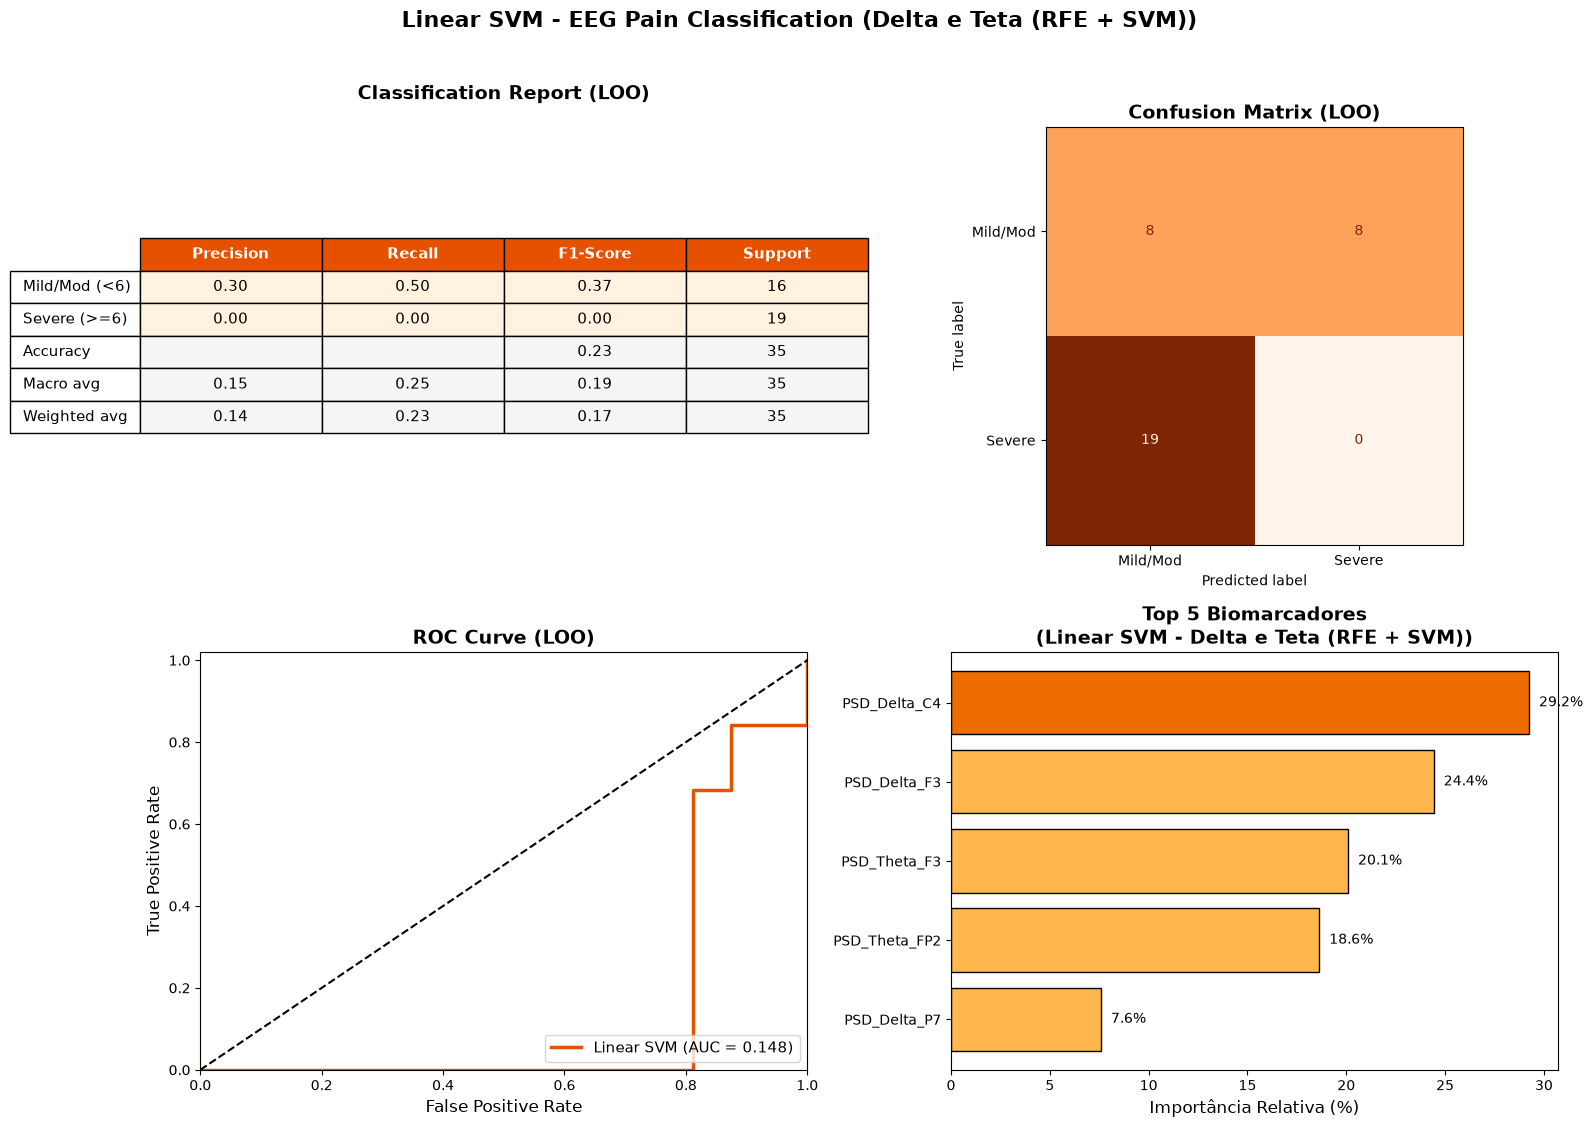


Gráfico salvo como: images\01_psd_delta_teta_rfe_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [9]:
# 1. Definir os nomes das features extraindo as colunas referentes a Delta OU Theta (Teta)
feature_names = [col for col in df_biomarcadores.columns if 'Delta' in col or 'Theta' in col]
current_category = "Delta e Teta (RFE + SVM)"

# 2. Criar a matriz X (features) e o vetor y (labels)
X = df_biomarcadores[feature_names].values
y = df_biomarcadores['pain_score'].values

if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV + RFE")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número máximo de features para exibir no gráfico

    # Estimador que o RFE usará para avaliar as features
    rfe_estimator = SVC(kernel='linear', random_state=42, class_weight='balanced')

    # Pipeline base atualizado com RFE
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', RFE(estimator=rfe_estimator)),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros incluindo a busca pela melhor quantidade de features
    param_dist = {
        'rfe__n_features_to_select': [5, 10, 15, 20],
        'rfe__step': [1, 2],
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    # Aumentado o n_iter para cobrir mais combinações já que adicionamos parâmetros do RFE
    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=20, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV com RFE...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para extração de importância
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # --- INÍCIO DO NOVO BLOCO RFE ---
    # Obter a máscara das features que sobreviveram ao RFE
    rfe_mask = search.best_estimator_.named_steps['rfe'].support_
    selected_feature_names = feature_names_filt[rfe_mask]
    
    # Extração de Importância baseada apenas nas features selecionadas
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    # Previne erros caso o RFE selecione menos features do que o num_top_features
    actual_top_features = min(num_top_features, len(selected_feature_names))
    
    print('-' * 55)
    print(f"\nTOP {actual_top_features} BIOMARCADORES SELECIONADOS ({classifier_name} + RFE):")
    for i, idx in enumerate(ranking[:actual_top_features], 1):
        print(f"  {i}. {selected_feature_names[idx]}: {importances_pct[idx]:.1f}% de importância")

    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {actual_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:actual_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {selected_feature_names[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma potência maior nesta região {efeito} a probabilidade matemática de Dor Severa (Classe 1).")
    # --- FIM DO NOVO BLOCO RFE ---

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:actual_top_features]
    bios_ordered  = selected_feature_names[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {actual_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '01_psd_delta_teta_rfe_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': len(selected_feature_names), # Salva a quantidade que o RFE escolheu
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")